# Parameter Grid Exploration – CRRLs

This notebook loads pre-computed χ² grids for Carbon Radio Recombination Lines (CRRLs),
explores the physical parameter space (Te, Ne, T0, L, vt), and identifies the optimal
solution for a given set of measurements.

## How to use this notebook

**You only need to edit one cell: `⚙️ 2 — User Parameters`.**  
Everything below runs automatically once you set your paths and parameters there.

---

## Workflow

| Step | What it does |
|------|--------------|
| 1 | **Imports & plot configuration** — load libraries (no editing needed) |
| 2 | **User parameters** — set paths, CSV file, and computation options |
| 3 | **χ² grid computation** — load NetCDF grids and compare model to measurements |
| 4 | **Best-fit solution selection** — define confidence regions via relative thresholds |
| 5 | **2D visualisations** — heatmaps and contours of the parameter space |
| 6 | **Fine selection** — apply a geometric mask in the (Te, L) plane |
| 7 | **Marginal histograms** — distribution of each parameter in the confidence region |
| 8 | **Optimal model vs. observed data** — compare modelled line width to measurements |

---

### Dependencies
```
numpy  pandas  xarray  matplotlib
spectral_tools  (local — install with: pip install -e .)
```


---
## 1 — Imports & plot configuration

*No editing needed.*


In [16]:
import os
import time
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Local modules — install once with: pip install -e .
import spectral_tools.graphics as graphics        # custom plot utilities
import spectral_tools.grid_exploration as grid    # χ² computation on NetCDF grids
import spectral_tools.modeling as mdl             # analytical line width model

%matplotlib widget
graphics.set_style()


---
## ⚙️  2 — User Parameters

> **Edit this cell.** Following cells read from these variables.


In [2]:
# =============================================================================
#  CONFIGURATION  —  edit here, do not touch anything below
# =============================================================================

# --- Source configuration ----------------------------------------------------
SOURCE  = 'CAS_A'   # Source identifier (must match 3_Stacking output)
USE_OFF = False            # True  → use the OFF-subtracted stacks
                           # False → use the ON stacks
_off_str   = '_OFF' if USE_OFF else ''
# --- Paths -------------------------------------------------------------------
PATH_GRIDS   = '../grids/coarse_grids/'  # folder containing grid-{n}.nc files
FILE_PATTERN = 'grid-{}.nc'                          # filename pattern
CSV_PATH     = '../data/fitresults/CAS_A/'             # folder containing fit measurements
PATH_PDF   = '../figures/Grid-exploration/' # Folder where figures will be written

# --- Quantum number subset to include in the χ² computation -----------------
N_SUBSET = np.arange(431, 850, 1)

# --- Reference χ²_min values for other beams ---------------------------------
# Useful for comparing pointings without rerunning the full computation.
MINI_BEAM3  = 0.5291611455622927
MINI_BEAM40 = 18.882964028602668
MINI_BEAM41 = 7.9484867299322


---
### 2b — Select input file


In [3]:
# List available CSV files
csv_list = sorted(os.listdir(CSV_PATH))
print(f'{len(csv_list)} file(s) available:')
for f in csv_list:
    print(' ', f)

# Select the file to process (change the index if needed)
csv_file = csv_list[1]
print('\nSelected file:', csv_file)


3 file(s) available:
  values_of_fit-CAS_A-3comp-0-new.csv
  values_of_fit-CAS_A-3comp-1-new.csv
  values_of_fit-CAS_A-3comp-2-new.csv

Selected file: values_of_fit-CAS_A-3comp-1-new.csv


---
## 3 — $\chi$² Grid Computation

`grid.compute_chi2_split` loads the NetCDF files for each quantum number `n` and
compares the model (deltaf, area) against the CSV measurements. The result is a
5D `xr.DataArray` (Te, Ne, T0, L, vt) containing the $\chi$² cumulated over all
quantum numbers.


In [4]:
t0 = time.time()
chi2_grid = grid.compute_chi2_split(
    PATH_GRIDS, FILE_PATTERN,
    CSV_PATH + csv_file,
    n_subset=N_SUBSET,
)
# Flatten to a DataFrame for tabular selections
df = chi2_grid.to_dataframe(name='chi2').reset_index()
print(f'χ² grid computed in {int(time.time()-t0)} s')
print(f'Shape: {df.shape}  |  columns: {list(df.columns)}')


[compute_chi2_split] Chi² grid shape: (98, 18, 50, 50, 30)
χ² grid computed in 106 s
Shape: (132300000, 6)  |  columns: ['Te', 'Ne', 'T0', 'L', 'vt', 'chi2']


In [5]:
# Original grid axes (needed to re-index heatmaps)
Te_orig = np.unique(df['Te'])
Ne_orig = np.unique(df['Ne'])
T0_orig = np.unique(df['T0'])
L_orig  = np.unique(df['L'])
vt_orig = np.unique(df['vt'])

for name, arr, unit in [
    ('Te', Te_orig, 'K'),
    ('Ne', Ne_orig, 'cm⁻³'),
    ('T0', T0_orig, 'K'),
    ('L',  L_orig,  'pc'),
    ('vt', vt_orig, 'km/s'),
]:
    print(f'{name:3s}: {arr[0]:.4g}–{arr[-1]:.4g} {unit}  ({len(arr)} pts)')


Te : 10–495 K  (98 pts)
Ne : 0.01–0.095 cm⁻³  (18 pts)
T0 : 0–4900 K  (50 pts)
L  : 0–49 pc  (50 pts)
vt : 0–29 km/s  (30 pts)


In [6]:
# Load measurements (used in section 8)
obs_df = pd.read_csv(CSV_PATH + csv_file)


---
## 4 — Best-fit Solution Selection

Relative thresholds above $\chi^2_{min}$ are used to define confidence regions
in the 5-dimensional parameter space.


In [7]:
chi2_min = df['chi2'].min()   # global minimum over the entire grid
chi2_lim = chi2_min * 1.5    # heatmap display ceiling (+50%)

# Subsets at different confidence levels
df_best   = df[df['chi2'] == chi2_min]             # exact best-fit solution
df_best15 = df[df['chi2'] <= 1.15 * chi2_min]     # +15% region
df_best30 = df[df['chi2'] <= 1.30 * chi2_min]     # +30% region

print(f'chi2_min = {chi2_min:.4f}')
print(f'Confidence region sizes: +15% = {len(df_best15)} points, +30% = {len(df_best30)} points')

# Display best-fit solution(s)
print(f'\nBest-fit solution(s) — {len(df_best)} point(s) at χ²_min:')
display(df_best.style
    .format({
        'Te':   '{:.1f}',
        'Ne':   '{:.4f}',
        'T0':   '{:.1f}',
        'L':    '{:.2f}',
        'vt':   '{:.2f}',
        'chi2': '{:.4f}',
    })
    .set_caption('Best-fit parameters')
    .highlight_min(subset=['chi2'], color='lightgreen')
)


chi2_min = 0.0358
Confidence region sizes: +15% = 47 points, +30% = 143 points

Best-fit solution(s) — 1 point(s) at χ²_min:


,Te,Ne,T0,L,vt,chi2
10976314,50.0,0.0200,1700.0,27.00,4.00,0.0358


---
## 5 — 2D Parameter Space Visualisation


### 5.1 Te – L plane  (marginalised over Ne, T0, vt)

The heatmap shows the χ² minimum projected onto the (Te, L) plane,
obtained by taking the minimum over all other axes via `pivot_table(aggfunc='min')`.


In [8]:
# χ² heatmap: minimum projected onto the (Te, L) plane
heatmap_TeL = df.pivot_table(index='Te', columns='L', values='chi2', aggfunc='min')
x_TeL = heatmap_TeL.columns.values  # L values
y_TeL = heatmap_TeL.index.values    # Te values
z_TeL = heatmap_TeL.values


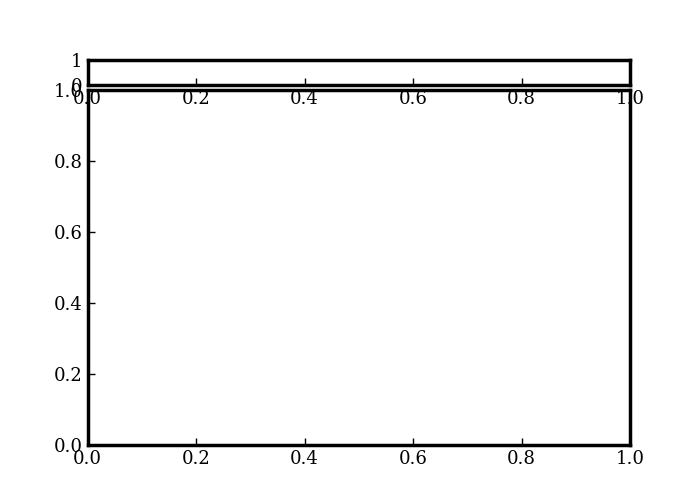

In [17]:
# Visualisation

fig_tel, ax_tel = plt.subplots(figsize=(7, 5))
div = make_axes_locatable(ax_tel)
cax = div.append_axes('top', size='7%', pad=0.05)

In [18]:
# Colour heatmap + confidence contour 
im = graphics.plot_chi2_heatmap(
    ax_tel, z_TeL, x_TeL, y_TeL,
    chi2_min=chi2_min, chi2_lim=chi2_lim,
    threshold=1.15, cmap='viridis', ylim=(10, 100),
)


ax_tel.set_xlabel('$L$ (pc)')
ax_tel.set_ylabel('$T_e$ (K)')

plt.colorbar(im, cax=cax, location='top')
cax.set_title('$\\chi^2$')
cax.axvline(1.15 * chi2_min, color='k', linestyle='dotted')

fig_tel.tight_layout()



In [19]:
fig_tel.savefig(PATH_PDF+SOURCE+_off_str+'_te_l.pdf')

### 5.2 Te – Ne plane with L-coloured contours

The background heatmap shows the $\chi^2$ minimum marginalised over (T0, L, vt).
Each coloured contour corresponds to a fixed value of L and delimits
the +15% confidence region, revealing the Te–Ne–L degeneracy.


In [20]:
# χ² heatmap: minimum projected onto the (Te, Ne) plane
heatmap_TeNe = df.pivot_table(index='Te', columns='Ne', values='chi2', aggfunc='min')
x_TeNe = heatmap_TeNe.columns.values  # Ne values
y_TeNe = heatmap_TeNe.index.values    # Te values
z_TeNe = heatmap_TeNe.values

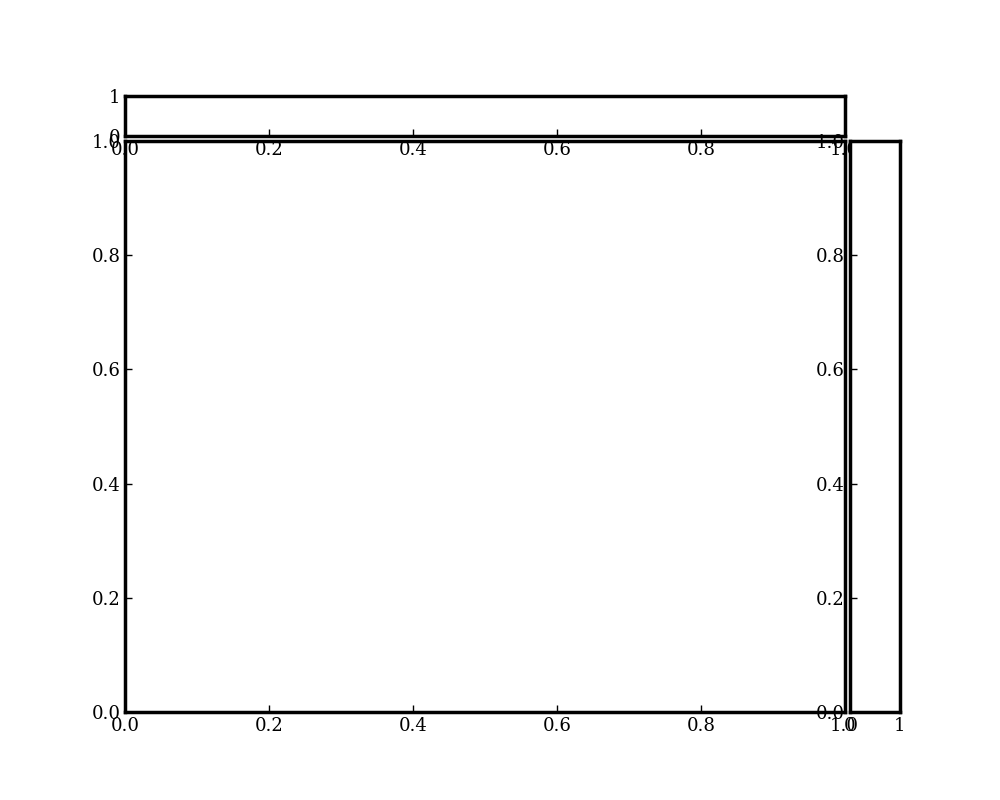

In [21]:
fig_tene, axs = plt.subplots(figsize=(10, 8))
div0    = make_axes_locatable(axs)
cax_top = div0.append_axes('top',   size='7%', pad=0.05)
cax_rgt = div0.append_axes('right', size='7%', pad=0.05)

In [25]:
axs.clear()
# Background heatmap (marginalised over T0, L, vt)
im_bg = graphics.plot_chi2_heatmap(
    axs, z_TeNe, x_TeNe, y_TeNe,
    chi2_min=chi2_min, chi2_lim=chi2_lim,
    threshold=1.15, cmap='Blues_r',
    ylim=(10, 100),
)

# Per-L coloured contours
graphics.plot_contours_by_param(
    axs, df,
    param_x='Ne', param_y='Te', param_color='L',
    param_vals=L_orig,
    chi2_min=chi2_min, threshold=1.15, cmap='jet',
)

# Best-fit annotation
df_opt_tene = df[df.chi2 == z_TeNe.min()]
xm, ym = df_opt_tene.Ne.values[0], df_opt_tene.Te.values[0]
txt  = '$\\chi^2_{\\mathrm{min}}$ at:\n'
txt += f'$T_e$ = {df_opt_tene.Te.values[0]} K\n'
txt += f'$n_e$ = {df_opt_tene.Ne.values[0] : .3f} cm⁻³\n'
txt += f'$T_0$ = {df_opt_tene.T0.values[0]} K\n'
txt += f'$L$   = {df_opt_tene.L.values[0]} pc\n'
txt += f'$v_t$ = {df_opt_tene.vt.values[0]} km/s'
axs.annotate(
    txt, (xm, ym), xytext=(0, 120), textcoords='offset points',
    color='k', arrowprops={'color': 'r', 'arrowstyle': '->'},
    bbox=dict(boxstyle='round,pad=0.5', ec='r', fc='w'),
    ha='center', va='center', multialignment='left',
)

axs.set_xlim(1e-2, 6e-2)
axs.set_xlabel('$n_e$ (cm⁻³)')
axs.set_ylabel('$T_e$ (K)')

# Colourbars
norm_L = mpl.colors.Normalize(vmin=L_orig.min(), vmax=L_orig.max())
fig_tene.colorbar(mpl.cm.ScalarMappable(norm=norm_L, cmap='jet'),
                  cax=cax_rgt, location='right', label='$L$ (pc)')
fig_tene.colorbar(im_bg, cax=cax_top, location='top', label='$\\chi^2$')
cax_top.axvline(1.15 * chi2_min, color='k')
cax_top.text(1.15 * chi2_min, -1, '$+15\\%$', va='bottom', ha='center')

fig_tene.tight_layout()

In [26]:
fig_tene.savefig(PATH_PDF+SOURCE+_off_str+'_te_ne_l.pdf')

---
## 6 — Fine Selection via Geometric Mask in the (Te, L) Plane

> **Edit this cell** with constraints on L. Base your selection on the Te/L heatmap

Regions of the (Te, L) space are excluded to retain only physically plausible
solutions. The condition `cond` defines points **to be masked out** (set to NaN).
Adjust as needed for each source or beam.  
 

In [28]:
# 2D Te×L grid for masking conditions
LL, TE = np.meshgrid(x_TeL, y_TeL)  # shape (nTe, nL)

# ── Exclusion condition ───────────────────────────────────────────────────
# Adjust per source/beam:
#   beam2 : cond = (LL < 21.5) | (TE < funclo(LL))
#   beam3 : cond = (LL < 9) | (LL > 12)
cond = (LL > 32) | (LL < 20)    # exclusion of some values of L

# Masked heatmaps — make_masked_heatmap is now in grid_exploration module
z_masked15 = grid.make_masked_heatmap(df_best15, x_TeL, y_TeL, cond)

# Retained solutions: χ² values present in the unmasked region
valid_chi2  = np.unique(z_masked15[~np.isnan(z_masked15)])
df_solution = df_best15[df_best15['chi2'].isin(valid_chi2)]

print(f'{len(df_solution)} point(s) retained after masking.')
display(df_solution.style
    .format({
        'Te':   '{:.1f}',
        'Ne':   '{:.4f}',
        'T0':   '{:.1f}',
        'L':    '{:.2f}',
        'vt':   '{:.2f}',
        'chi2': '{:.4f}',
    })
    .highlight_min(subset=['chi2'], color='lightgreen')
)


5 point(s) retained after masking.


,Te,Ne,T0,L,vt,chi2
10976254,50.0,0.0200,1700.0,25.00,4.00,0.0399
10976284,50.0,0.0200,1700.0,26.00,4.00,0.0367
10976314,50.0,0.0200,1700.0,27.00,4.00,0.0358
10976344,50.0,0.0200,1700.0,28.00,4.00,0.0370
10976374,50.0,0.0200,1700.0,29.00,4.00,0.0404


In [34]:
# ── Parameter range summary ───────────────────────────────────────────────
chi2_opt = df_solution['chi2'].min()
df_opt   = df_solution[df_solution['chi2'] == chi2_opt]

summary = pd.DataFrame({
    'min':     {col: df_solution[col].min() for col in ['Te', 'Ne', 'T0', 'L', 'vt']},
    'max':     {col: df_solution[col].max() for col in ['Te', 'Ne', 'T0', 'L', 'vt']},
    'optimal': {col: df_opt[col].values[0]  for col in ['Te', 'Ne', 'T0', 'L', 'vt']},
})

units = {'Te': 'K', 'Ne': 'cm⁻³', 'T0': 'K', 'L': 'pc', 'vt': 'km/s'}
summary.index = [f'{p} ({units[p]})' for p in summary.index]

display(summary.style
    .format('{:.4g}')
    .set_caption('Selected parameter ranges after masking')
)


,min,max,optimal
Te (K),50,50,50
Ne (cm⁻³),0.02,0.02,0.02
T0 (K),1700,1700,1700
L (pc),25,29,27
vt (km/s),4,4,4


---
## 7 — Marginal Parameter Histograms

Distribution of each parameter within the selected confidence region.
The red line marks the optimal value.


array([ 10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,  65,  70,
        75,  80,  85,  90,  95, 100, 105, 110, 115, 120, 125, 130, 135,
       140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200,
       205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255, 260, 265,
       270, 275, 280, 285, 290, 295, 300, 305, 310, 315, 320, 325, 330,
       335, 340, 345, 350, 355, 360, 365, 370, 375, 380, 385, 390, 395,
       400, 405, 410, 415, 420, 425, 430, 435, 440, 445, 450, 455, 460,
       465, 470, 475, 480, 485, 490, 495])

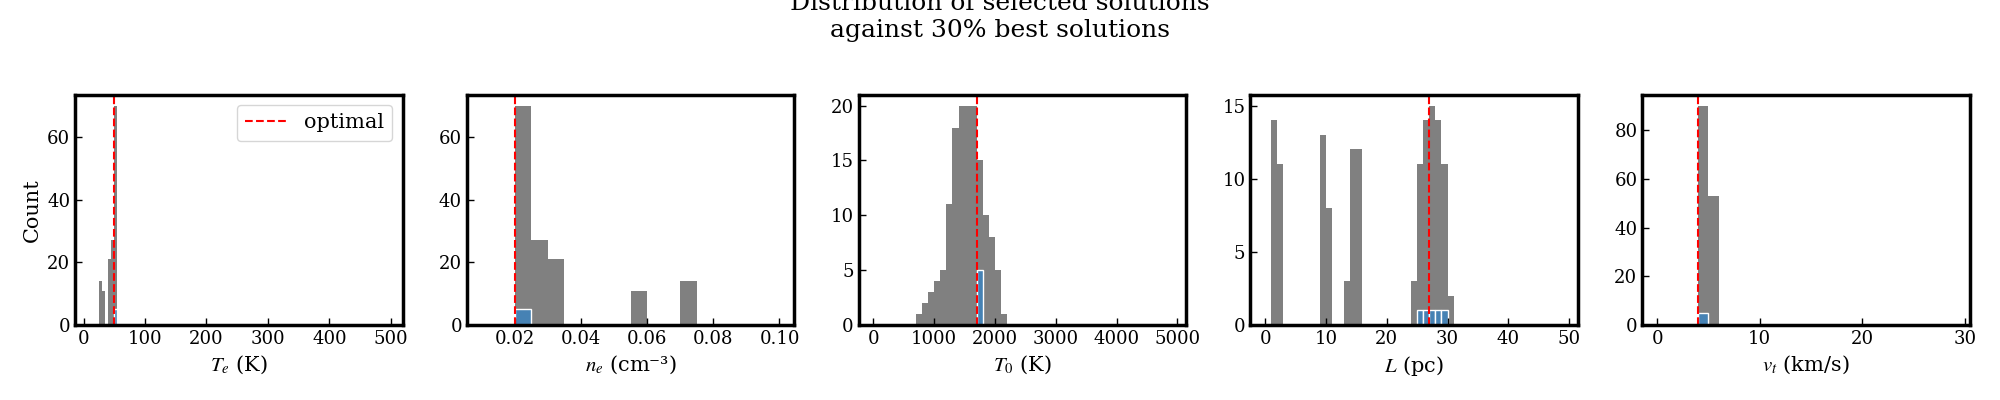

In [41]:
PARAMS = ['Te', 'Ne', 'T0', 'L', 'vt']
PARAM_AXES = {'Te': Te_orig, 'Ne': Ne_orig, 'T0': T0_orig,
              'L': L_orig,   'vt': vt_orig}
PARAM_LABELS = {
    'Te': '$T_e$ (K)',      'Ne': '$n_e$ (cm⁻³)',
    'T0': '$T_0$ (K)',      'L':  '$L$ (pc)',
    'vt': '$v_t$ (km/s)',
}

fig_hist, axhists = plt.subplots(1, 5, figsize=(20, 4))
for ax_h, p in zip(axhists, PARAMS):
    ax_orig = PARAM_AXES[p]
    d_step  = ax_orig[1] - ax_orig[0]         # grid step size
    exten   = np.unique(df_best30[p])
    bins    = np.arange(ax_orig[0], ax_orig[-1] + d_step, d_step)
    ax_h.hist(df_best30[p], bins=bins, color="gray")
    ax_h.hist(df_solution[p], bins=bins, color='steelblue', edgecolor='white')
    ax_h.axvline(df_opt[p].values[0], color='r', lw=1.5, ls='--', label='optimal')
    ax_h.set_xlabel(PARAM_LABELS[p])
    if p == 'Te':
        ax_h.set_ylabel('Count')
        ax_h.legend()

fig_hist.suptitle('Distribution of selected solutions\nagainst 30% best solutions', y=1.02)
fig_hist.tight_layout()


In [43]:
fig_hist.savefig(PATH_PDF+SOURCE+_off_str+'_solutions_hist.pdf')

---
## 8 — Optimal Model vs. Observed Data

Comparison of the modelled Voigt line width against the measurements
as a function of quantum number `n`. The shaded envelope spans the range
of Te values within the retained solution (Te uncertainty at fixed Ne, T0, L, vt).


In [44]:
# ── Optimal parameters ────────────────────────────────────────────────────
Te_opt = df_opt.Te.values[0]
Ne_opt = df_opt.Ne.values[0]
T0_opt = df_opt.T0.values[0]
L_opt  = df_opt.L.values[0]
vt_opt = df_opt.vt.values[0]

print(f'Optimal: Te={Te_opt} K | Ne={Ne_opt:.4f} cm⁻³ | '
      f'T0={T0_opt} K | L={L_opt} pc | vt={vt_opt} km/s')


Optimal: Te=50 K | Ne=0.0200 cm⁻³ | T0=1700 K | L=27 pc | vt=4 km/s


In [64]:
# ── Observed data ─────────────────────────────────────────────────────────
# obs_df already loaded in section 3
QUAN   = obs_df['n'].values
WV     = obs_df['wV'].values    # measured Voigt width [Hz]
DWV    = obs_df['dwV'].values   # uncertainty on wV

# Uncertainty in n (grid resolution, typically ±10 channels)
D_QUAN = np.array([[QUAN[i], QUAN[i+1]] for i in range(len(QUAN)-1)])
XERR = D_QUAN[:,1]-D_QUAN[:,0]
XERR = np.concatenate(([XERR[0]],XERR))

# Continuous grid for model evaluation
quantum = np.arange(QUAN.min(), QUAN.max() + 1)

# ── Model evaluation ──────────────────────────────────────────────────────
# total_broadening returns the Voigt FWHM in MHz → convert to Hz
model_opt = mdl.total_broadening(quantum, Ne_opt, Te_opt, T0_opt, vt_opt) * 1e6

# Envelope spanning ALL selected solutions (all parameters varying)
all_models = np.array([
    mdl.total_broadening(quantum, row.Ne, row.Te, row.T0, row.vt) * 1e6
    for _, row in df_solution.iterrows()
])
model_min = all_models.min(axis=0)
model_max = all_models.max(axis=0)



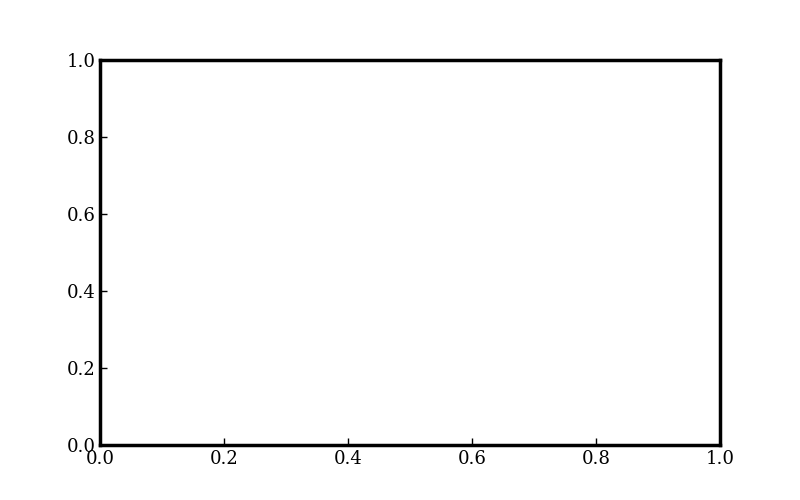

In [47]:
# ── Figure ────────────────────────────────────────────────────────────────
fig_model, ax_w = plt.subplots(figsize=(8, 5))


In [65]:
ax_w.clear()

# Figure plotting

graphics.set_axes(ax_w)
ax_w.set_yscale('log')
ax_w.errorbar(QUAN, WV, xerr=XERR, yerr=DWV,
              fmt='.', color='steelblue', label='Observed data')
ax_w.plot(quantum, model_opt, ls='dotted', color='steelblue', label='Optimal model')
ax_w.fill_between(
    quantum, model_min, model_max,
    color='steelblue', alpha=0.3,
    label=f'Model envelope ({len(df_solution)} solutions)',
)
ax_w.set_xlabel('$n$')
ax_w.set_ylabel('Voigt width $w_V$ (Hz)')
ax_w.set_xlim(400, 850)
ax_w.set_ylim(5e2, 1e5)
ax_w.legend()
fig_model.tight_layout()


In [66]:
fig_model.savefig(PATH_PDF+SOURCE+_off_str+'_obs-vs-model.pdf')